# Expert alongtrack spectra : direct vs. cross-track integrated

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = "/Volumes/PortableSSD/diags_2024/"
SEGMENT_LENGTH_KM = 250.0
ds_segments2D = xr.open_dataset(DATA_DIR+f'swot_segments2D_{int(SEGMENT_LENGTH_KM)}km_demean.nc') 
ds_segments = xr.open_dataset(DATA_DIR+f'swot_segments_{int(SEGMENT_LENGTH_KM)}km_demean.nc')

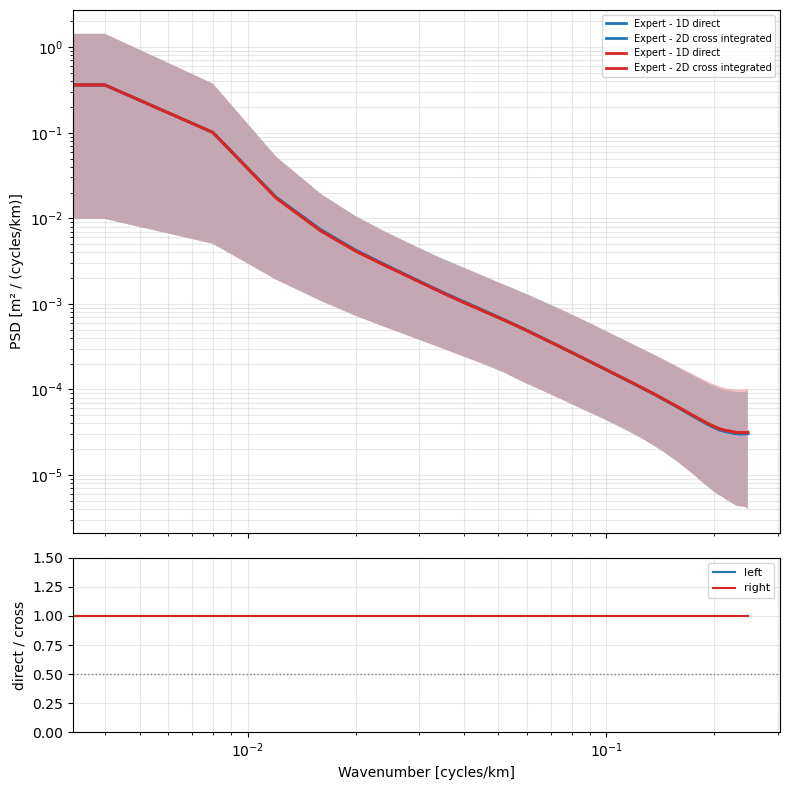

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():   
    k = ds_segments2D['wavenumber'].values
    psd_stack = ds_segments['psd'].where(ds_segments.swath==swath,drop=True).values
    psd2D_stack = ds_segments2D['psd'].where(ds_segments2D.swath==swath,drop=True).values
    
    psd_median = np.nanmean(psd_stack, axis=0)
    psd_lo, psd_hi = np.nanpercentile(psd_stack, [5, 95], axis=0)
    psd2D_median = np.nanmean(psd2D_stack, axis=0)
    psd2D_lo, psd2D_hi = np.nanpercentile(psd2D_stack, [5, 95], axis=0)
    
    ax = axs[0]
    ax.fill_between(k, psd_lo, psd_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, psd_median, c=c, lw=2, label=f'Expert - 1D direct')
    ax.fill_between(k, psd2D_lo, psd2D_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, psd2D_median, c=c, lw=2, label=f'Expert - 2D cross integrated')
    
    axs[1].semilogx(k, psd_median / psd2D_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

ax=axs[1]
ax.set_ylabel('direct / cross')
ax.axhline(0.5, c='0.5', ls=':', lw=1)
ax.set_xlabel('Wavenumber [cycles/km]')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8)
ax.set_ylim(0.,1.5)

fig.tight_layout()

In [4]:
lat_bin_edges = np.arange(-60,80,20)

binned = ds_segments[['lat_mean','psd']].groupby_bins('lat_mean',bins=lat_bin_edges).mean()
binned2D = ds_segments2D[['lat_mean','psd']].groupby_bins('lat_mean',bins=lat_bin_edges).mean()
k = ds_segments['wavenumber'].values



In [5]:
import cmocean
cmap = cmocean.cm.solar(np.linspace(0,1,binned.lat_mean_bins.size))

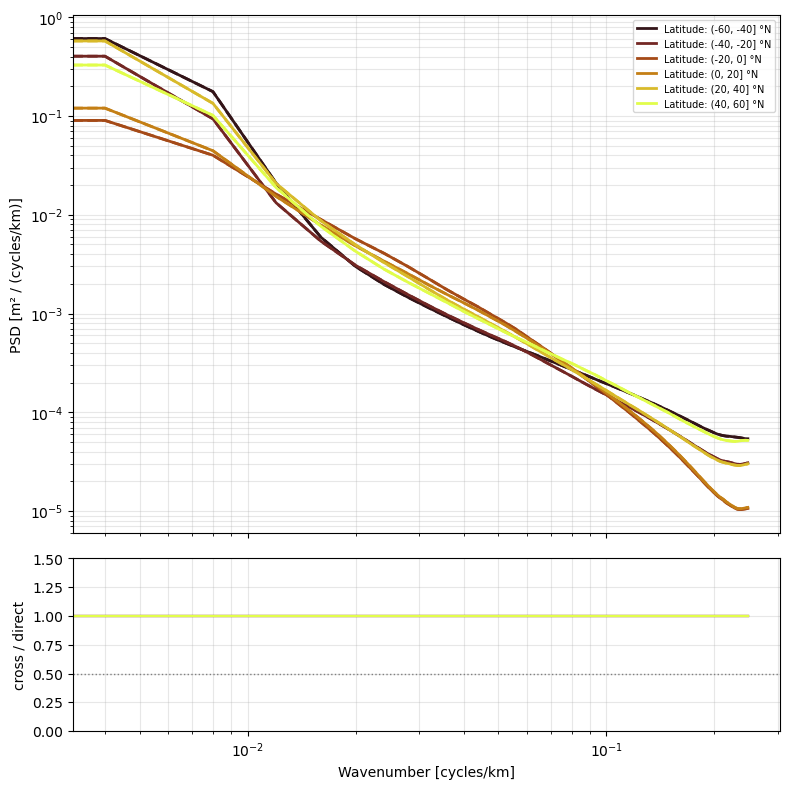

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

for i,l in enumerate(binned.lat_mean_bins):   
    ax = axs[0]
    ax.loglog(k, binned.sel(lat_mean_bins=l).psd, c=cmap[i], lw=2, label= f'Latitude: {l.values} °N')
    ax.loglog(k, binned2D.sel(lat_mean_bins=l).psd, c=cmap[i], lw=2, ls = '--')
    
    axs[1].semilogx(k, binned2D.sel(lat_mean_bins=l).psd / binned.sel(lat_mean_bins=l).psd, c=cmap[i], lw=1.5)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)
#plt.colorbar(sc,ax=axs[0])
ax=axs[1]
ax.set_ylabel('cross / direct')
ax.axhline(0.5, c='0.5', ls=':', lw=1)
ax.set_xlabel('Wavenumber [cycles/km]')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(0.,1.5)

fig.tight_layout()